# Validación Stanley Final — Town07

Ruta **no vista** durante el tuneo. Controlador con ganancias óptimas `ke=2.50`, `k_ff=2.50` (tuneadas en Town03 con PINN1-v7).  
Métricas reportadas según sección 4.2 de la tesis.

## C00 — Carga de datos y métricas (sec. 4.2)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 11,
    'axes.titlesize': 12, 'axes.labelsize': 11,
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'legend.fontsize': 10, 'axes.linewidth': 0.8,
    'grid.linewidth': 0.5, 'grid.alpha': 0.4,
    'figure.dpi': 130, 'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

C_MAIN = '#2E75B6'   # azul IEEE
C_REF  = '#555555'   # gris referencia

# ── Cargar datos ──────────────────────────────────────────────────────────────
data = np.load('data_town07_stanley_final.npy', allow_pickle=True).item()
traj = np.load('traj_dataset_Town07.npy',       allow_pickle=True).item()

# Trayectoria de referencia
x_ref       = traj['x']
y_ref       = traj['y']
yaw_ref_raw = traj['yaw']
yaw_ref     = np.arctan2(np.sin(yaw_ref_raw), np.cos(yaw_ref_raw))
s_ref       = traj['s']
path_xy     = np.column_stack([x_ref, y_ref])
N_PATH      = len(x_ref)

# Datos del vehiculo
x_v         = data['x']
y_v         = data['y']
yaw_v       = data['yaw']
t_v         = data['time']
vx_v        = data['vx']
vref_v      = data['target_speed']
steer_rad_v = data['steer_rad']   # steer_expect [rad], sin normalizar

# ── Matching de waypoints con orientacion compatible ──────────────────────────
# Se penalizan candidatos cuyo yaw_ref difiere >90 del yaw del vehiculo
# para evitar mismatch en tramos paralelos/opuestos (sec. 4.2)
hint = 0
e_k_arr     = []   # error lateral sec 4.2.1
psi_err_arr = []   # error orientacion sec 4.2.2
s_v_arr     = []

for i in range(len(x_v)):
    lo = max(0, hint - 10)
    hi = min(N_PATH - 1, hint + 300)
    d2 = (path_xy[lo:hi, 0] - x_v[i])**2 + (path_xy[lo:hi, 1] - y_v[i])**2
    yaw_cands    = yaw_ref[lo:hi]
    heading_diff = np.abs(np.arctan2(np.sin(yaw_cands - yaw_v[i]),
                                      np.cos(yaw_cands - yaw_v[i])))
    d2 = d2 + (heading_diff > np.radians(90)) * 1e9
    idx  = lo + int(np.argmin(d2))
    hint = idx

    xr, yr, psi_r = x_ref[idx], y_ref[idx], yaw_ref[idx]

    # Error lateral — formula tesis ec. 4.2.1
    e_k = (y_v[i] - yr) * np.cos(psi_r) - (x_v[i] - xr) * np.sin(psi_r)
    e_k_arr.append(float(e_k))

    # Error de orientacion — formula tesis ec. 4.2.2
    psi_err = float(np.arctan2(np.sin(yaw_v[i] - psi_r), np.cos(yaw_v[i] - psi_r)))
    psi_err_arr.append(psi_err)

    s_v_arr.append(float(s_ref[idx]))

e_k_arr     = np.array(e_k_arr)
psi_err_arr = np.array(psi_err_arr)
s_v_arr     = np.array(s_v_arr)

# ── Metricas sec. 4.2 ─────────────────────────────────────────────────────────
# 4.2.1 Error lateral
RMSE_cte = float(np.sqrt(np.mean(e_k_arr**2)))
MAE_cte  = float(np.mean(np.abs(e_k_arr)))
e_max    = float(np.max(np.abs(e_k_arr)))

# 4.2.2 Error de orientacion
RMSE_psi = float(np.sqrt(np.mean(psi_err_arr**2)))

# 4.2.3 Suavidad — variacion total del angulo de direccion
TV_steer = float(np.sum(np.abs(np.diff(steer_rad_v))))

# Extra — RMSE velocidad
RMSE_spd = float(np.sqrt(np.mean((vx_v - vref_v)**2)))

print('=' * 58)
print('  Stanley Final | Town07 (ruta no vista)')
print('  ke=2.50  k_ff=2.50  |  v_18_25')
print('=' * 58)
print(f"  {'Metrica':<32} {'Valor':>12}")
print('  ' + '-' * 46)
print(f"  {'RMSE_cte  [m]':<32} {RMSE_cte:>12.4f}")
print(f"  {'MAE_cte   [m]':<32} {MAE_cte:>12.4f}")
print(f"  {'E_max     [m]':<32} {e_max:>12.4f}")
print(f"  {'RMSE_psi  [deg]':<32} {np.degrees(RMSE_psi):>12.4f}")
print(f"  {'TV_steer  [rad]':<32} {TV_steer:>12.4f}")
print(f"  {'RMSE_vel  [m/s]':<32} {RMSE_spd:>12.4f}")
print(f"  {'N pasos':<32} {len(x_v):>12}")
print(f"  {'Duracion  [s]':<32} {t_v[-1]:>12.1f}")
print('=' * 58)

  Stanley Final | Town07 (ruta no vista)
  ke=2.50  k_ff=2.50  |  v_18_25
  Metrica                                 Valor
  ----------------------------------------------
  RMSE_cte  [m]                          1.1276
  MAE_cte   [m]                          0.5887
  E_max     [m]                          6.1779
  RMSE_psi  [deg]                       15.2320
  TV_steer  [rad]                       69.7674
  RMSE_vel  [m/s]                        9.2486
  N pasos                                  2869
  Duracion  [s]                           143.4


## C01 — Trayectoria XY

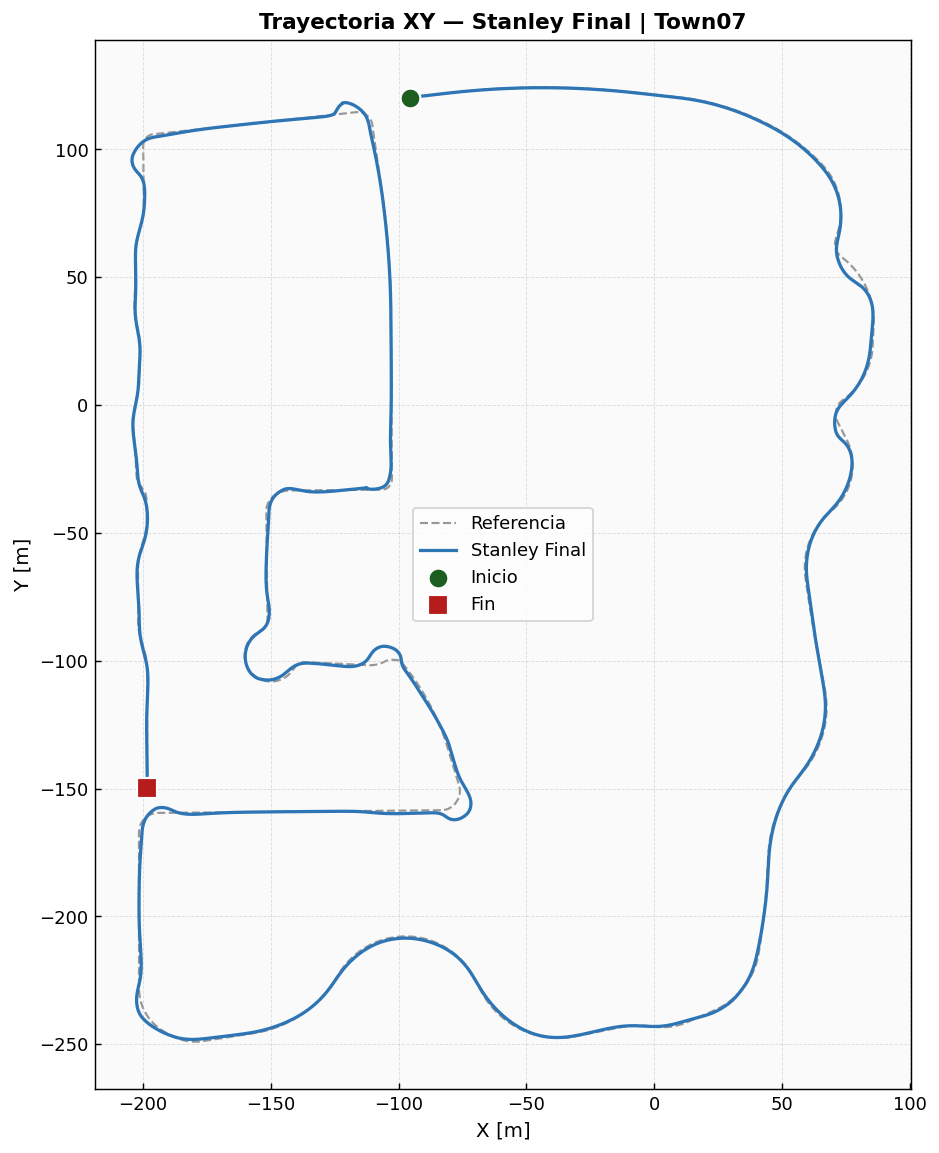

Guardada: stanley_town07_traj_xy.png


In [3]:
fig, ax = plt.subplots(figsize=(10, 9))
ax.set_facecolor('#FAFAFA')
ax.plot(x_ref, y_ref, color=C_REF, lw=1.2, ls='--', alpha=0.6, label='Referencia', zorder=1)
ax.plot(x_v,   y_v,   color=C_MAIN, lw=1.8,           label='Stanley Final',      zorder=3)
ax.scatter(x_v[0],  y_v[0],  s=120, c='#1B5E20', zorder=5, marker='o',
           edgecolors='white', lw=1.2, label='Inicio')
ax.scatter(x_v[-1], y_v[-1], s=120, c='#B71C1C', zorder=5, marker='s',
           edgecolors='white', lw=1.2, label='Fin')
ax.set_xlabel('X [m]'); ax.set_ylabel('Y [m]')
ax.set_title('Trayectoria XY — Stanley Final | Town07', fontweight='bold')
ax.legend(); ax.set_aspect('equal')
ax.grid(True, ls='--', alpha=0.4); ax.tick_params(direction='in')
plt.tight_layout()
plt.savefig('stanley_town07_traj_xy.png', dpi=300)
plt.show()
print('Guardada: stanley_town07_traj_xy.png')

## C02 — Error lateral CTE (sec. 4.2.1)

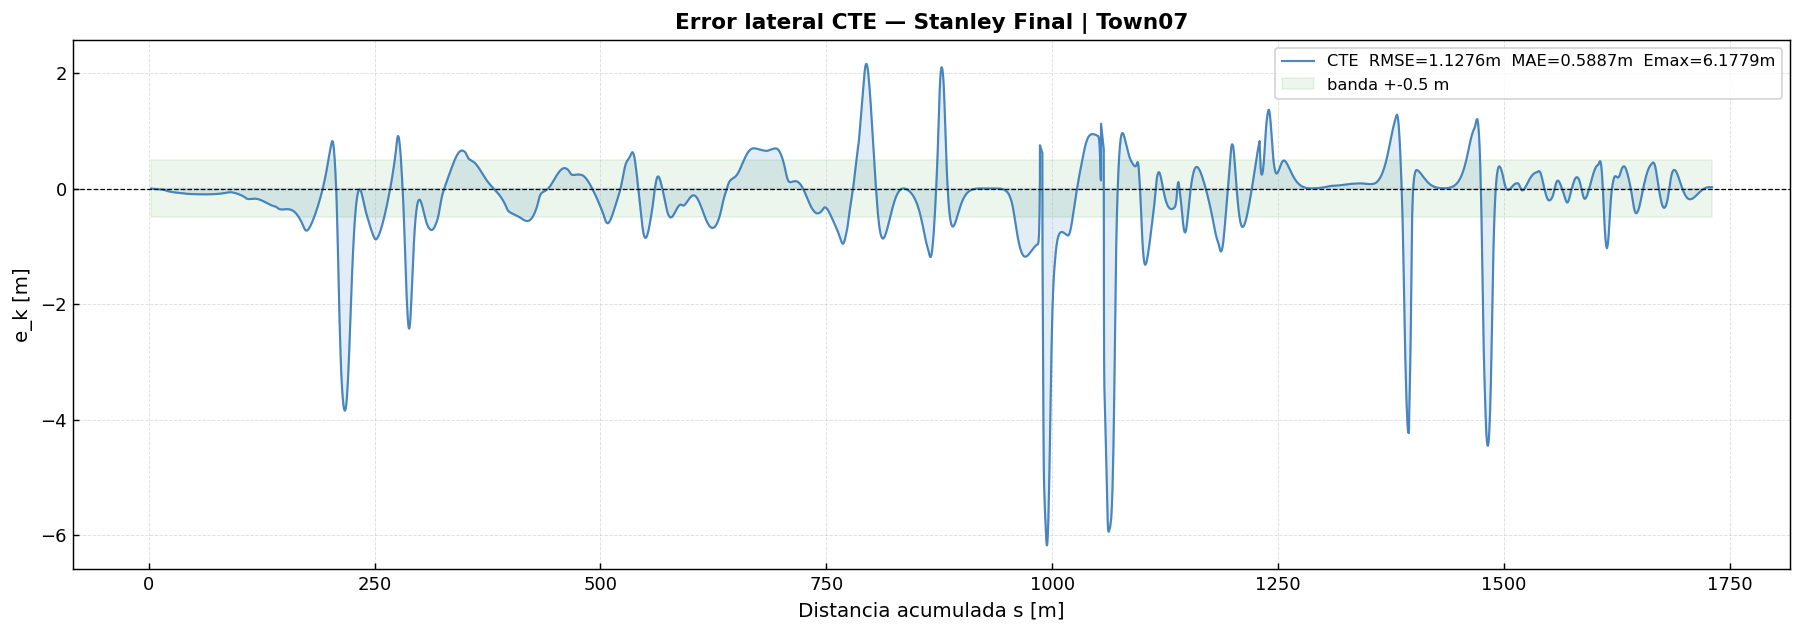

Guardada: stanley_town07_cte.png


In [4]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(s_v_arr, e_k_arr, color=C_MAIN, lw=1.2, alpha=0.85,
        label=f'CTE  RMSE={RMSE_cte:.4f}m  MAE={MAE_cte:.4f}m  Emax={e_max:.4f}m')
ax.axhline(0, color='k', lw=0.7, ls='--')
ax.fill_between(s_v_arr, e_k_arr, 0, where=(e_k_arr > 0), alpha=0.13, color=C_MAIN)
ax.fill_between(s_v_arr, e_k_arr, 0, where=(e_k_arr < 0), alpha=0.13, color=C_MAIN)
ax.fill_between([s_v_arr.min(), s_v_arr.max()], -0.5, 0.5,
                alpha=0.07, color='green', label='banda +-0.5 m')
ax.set_xlabel('Distancia acumulada s [m]')
ax.set_ylabel('e_k [m]')
ax.set_title('Error lateral CTE — Stanley Final | Town07', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, ls='--'); ax.tick_params(direction='in')
plt.tight_layout()
plt.savefig('stanley_town07_cte.png', dpi=300)
plt.show()
print('Guardada: stanley_town07_cte.png')

## C03 — Error de orientacion y velocidad (sec. 4.2.2)

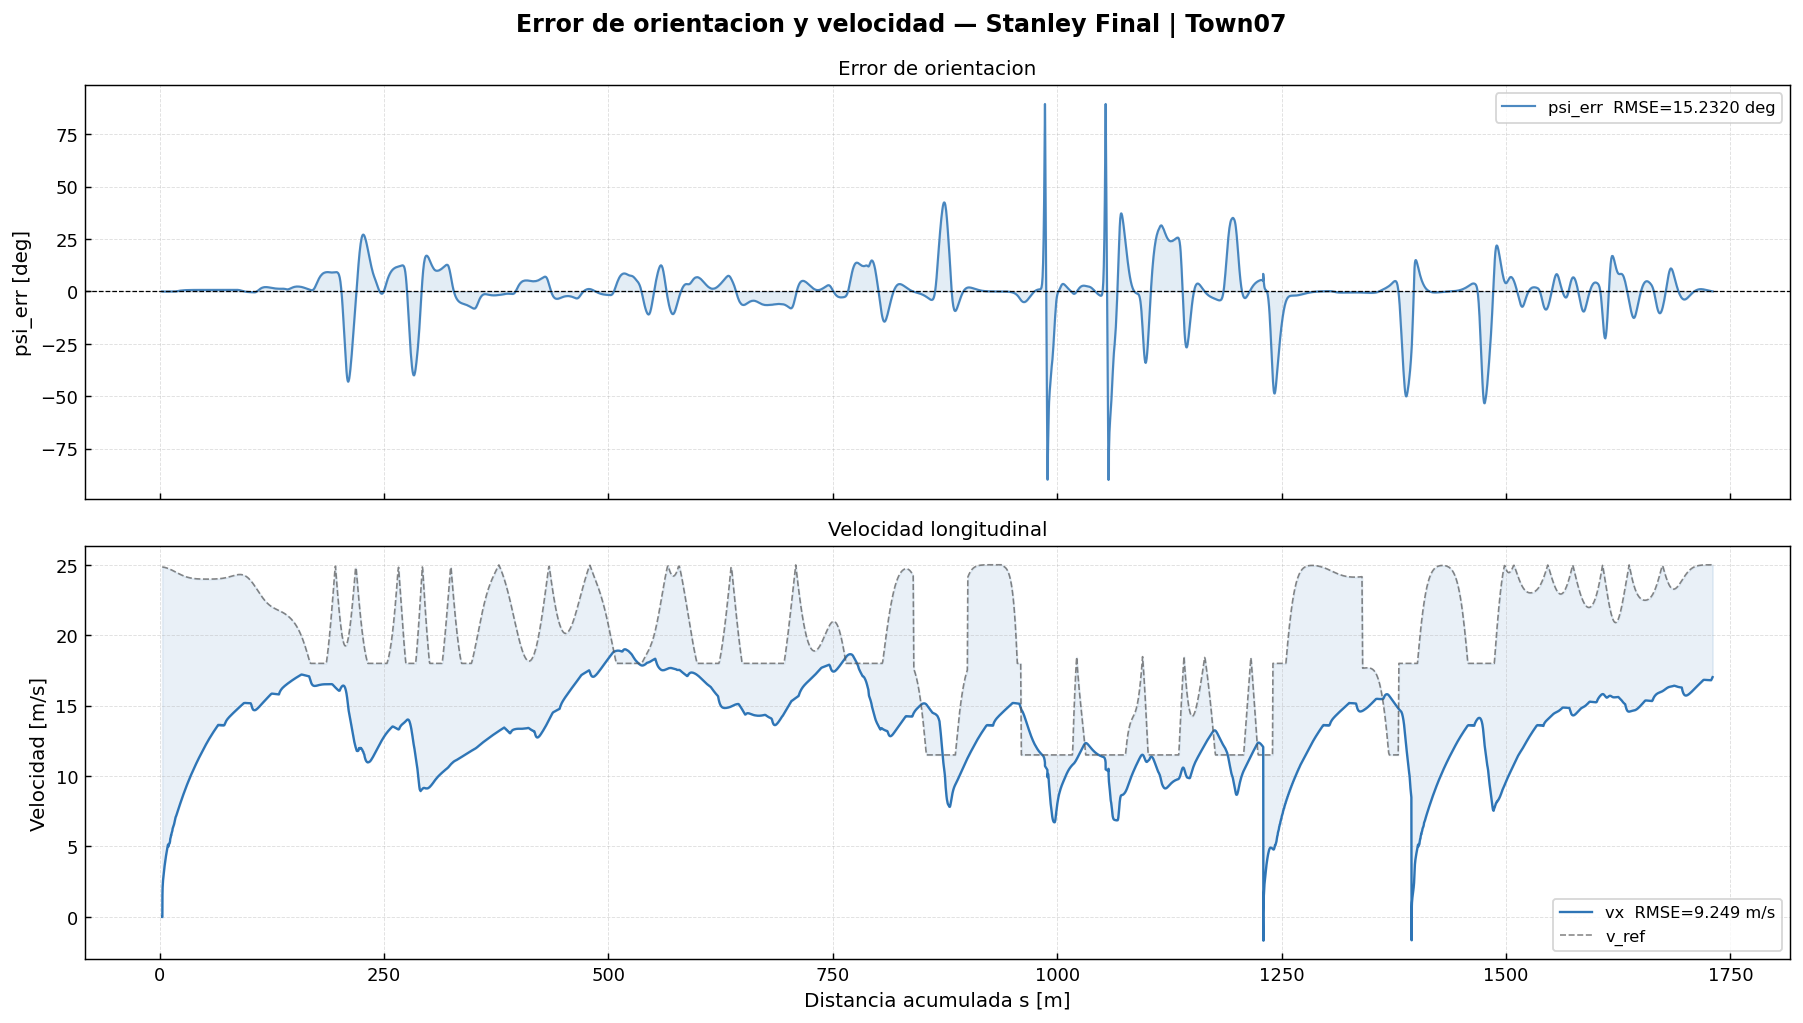

Guardada: stanley_town07_heading_vel.png


In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('Error de orientacion y velocidad — Stanley Final | Town07',
             fontweight='bold')

ax0 = axes[0]
ax0.plot(s_v_arr, np.degrees(psi_err_arr), color=C_MAIN, lw=1.2, alpha=0.85,
         label=f'psi_err  RMSE={np.degrees(RMSE_psi):.4f} deg')
ax0.axhline(0, color='k', lw=0.7, ls='--')
ax0.fill_between(s_v_arr, np.degrees(psi_err_arr), 0, alpha=0.13, color=C_MAIN)
ax0.set_ylabel('psi_err [deg]')
ax0.set_title('Error de orientacion', fontsize=11)
ax0.legend(fontsize=9); ax0.grid(True, ls='--'); ax0.tick_params(direction='in')

ax1 = axes[1]
ax1.plot(s_v_arr, vx_v,   color=C_MAIN, lw=1.3,
         label=f'vx  RMSE={RMSE_spd:.3f} m/s')
ax1.plot(s_v_arr, vref_v, color=C_REF,  lw=0.9, ls='--', alpha=0.7, label='v_ref')
ax1.fill_between(s_v_arr, vx_v, vref_v, alpha=0.10, color=C_MAIN)
ax1.set_xlabel('Distancia acumulada s [m]')
ax1.set_ylabel('Velocidad [m/s]')
ax1.set_title('Velocidad longitudinal', fontsize=11)
ax1.legend(fontsize=9); ax1.grid(True, ls='--'); ax1.tick_params(direction='in')

plt.tight_layout()
plt.savefig('stanley_town07_heading_vel.png', dpi=300)
plt.show()
print('Guardada: stanley_town07_heading_vel.png')

## C04 — Señal de direccion (sec. 4.2.3)

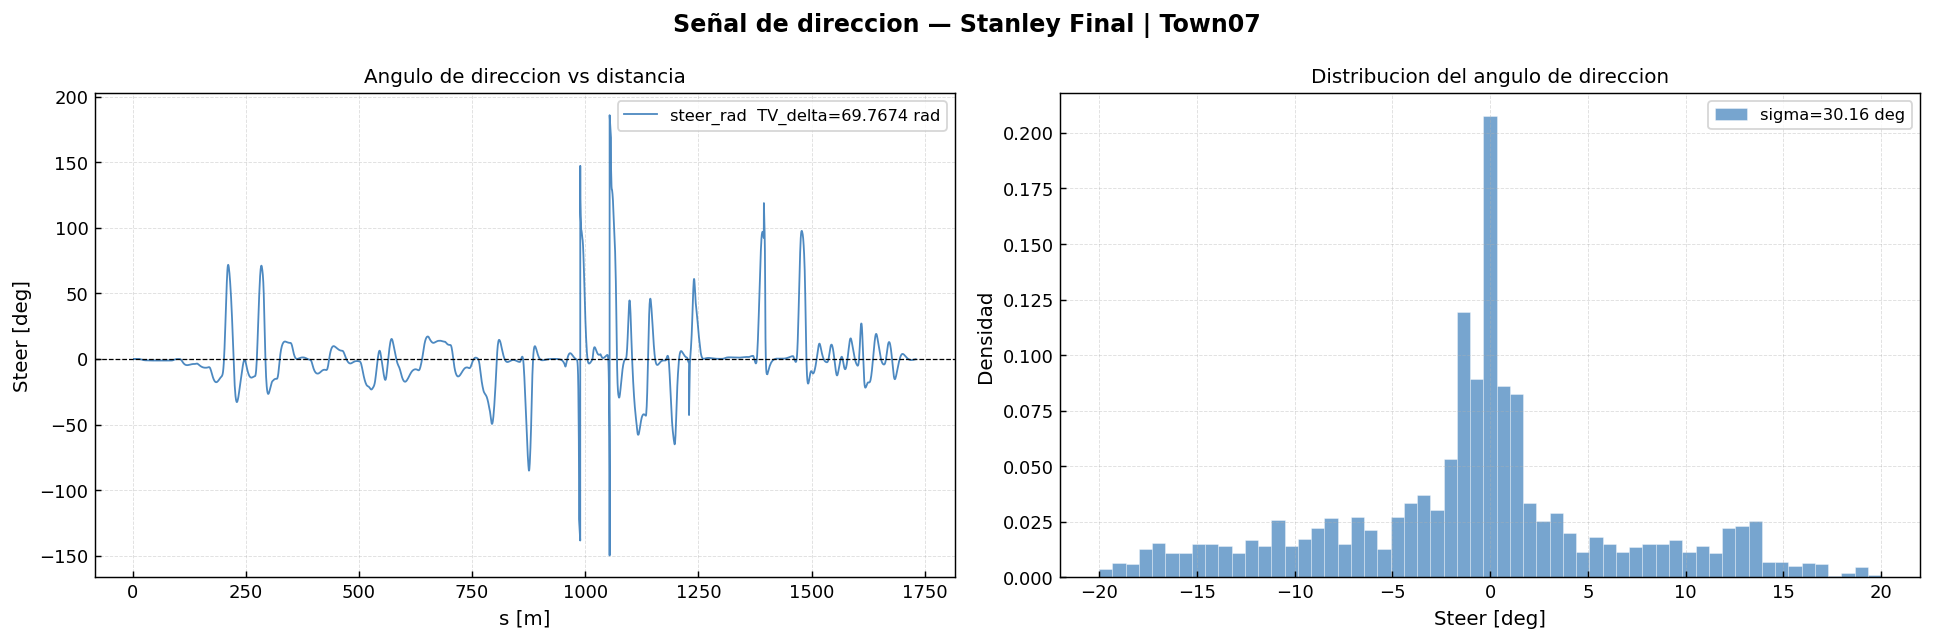

Guardada: stanley_town07_steer.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Señal de direccion — Stanley Final | Town07', fontweight='bold')

ax_s = axes[0]
ax_s.plot(s_v_arr, np.degrees(steer_rad_v), color=C_MAIN, lw=1.0, alpha=0.85,
          label=f'steer_rad  TV_delta={TV_steer:.4f} rad')
ax_s.axhline(0, color='k', lw=0.7, ls='--')
ax_s.set_xlabel('s [m]'); ax_s.set_ylabel('Steer [deg]')
ax_s.set_title('Angulo de direccion vs distancia', fontsize=11)
ax_s.legend(fontsize=9); ax_s.grid(True, ls='--'); ax_s.tick_params(direction='in')

ax_h = axes[1]
bins = np.linspace(-20, 20, 60)
ax_h.hist(np.degrees(steer_rad_v), bins=bins, color=C_MAIN, alpha=0.65,
          density=True, edgecolor='white', lw=0.3,
          label=f'sigma={np.degrees(np.std(steer_rad_v)):.2f} deg')
ax_h.set_xlabel('Steer [deg]'); ax_h.set_ylabel('Densidad')
ax_h.set_title('Distribucion del angulo de direccion', fontsize=11)
ax_h.legend(fontsize=9); ax_h.grid(True, ls='--'); ax_h.tick_params(direction='in')

plt.tight_layout()
plt.savefig('stanley_town07_steer.png', dpi=300)
plt.show()
print('Guardada: stanley_town07_steer.png')

## C05 — Panel resumen 2x3 *(figura principal)*

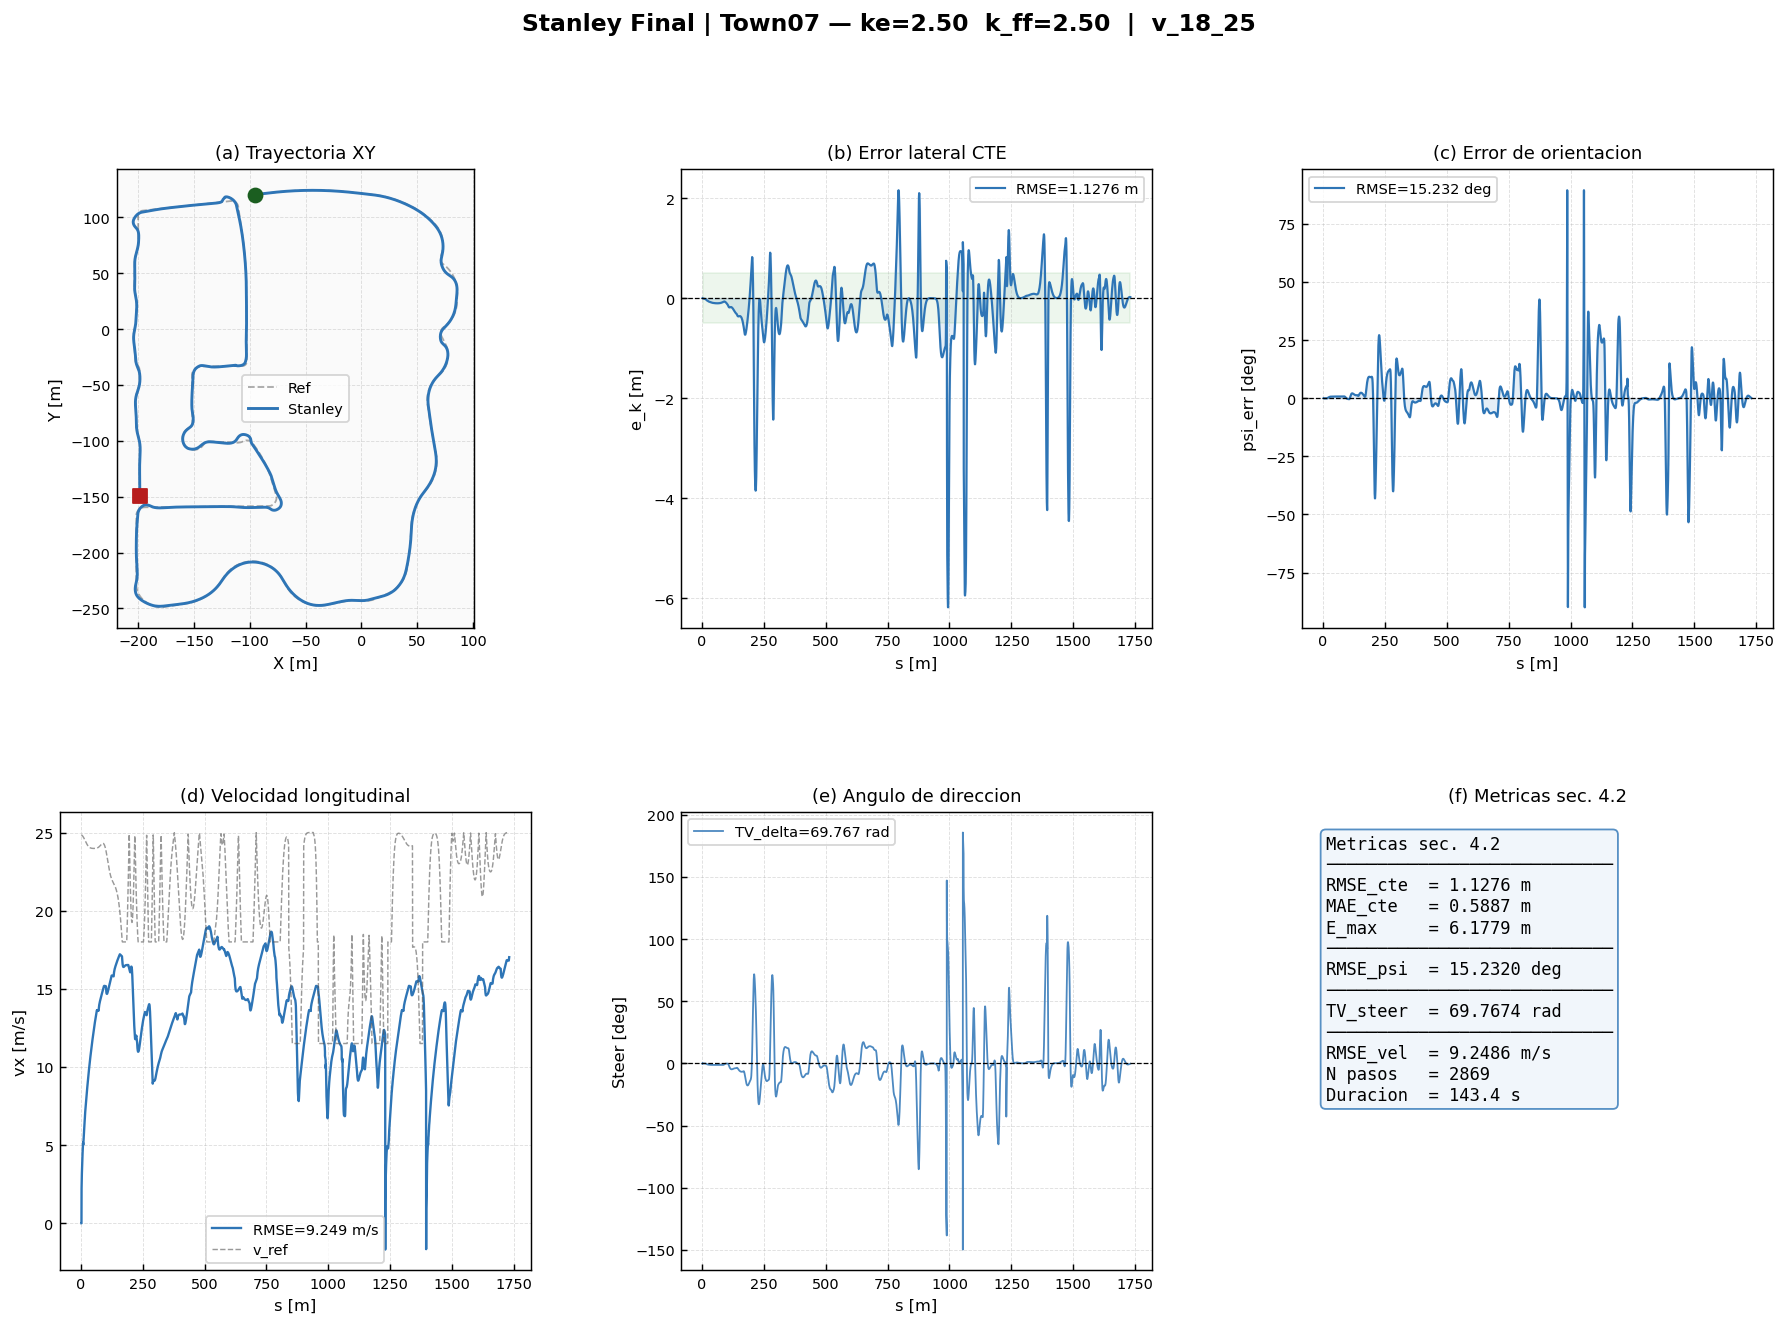

Guardada: stanley_town07_panel_resumen.png  <- FIGURA PRINCIPAL


In [7]:
fig = plt.figure(figsize=(17, 11))
fig.suptitle('Stanley Final | Town07 — ke=2.50  k_ff=2.50  |  v_18_25',
             fontsize=13, fontweight='bold', y=0.99)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.40, wspace=0.32)

# (a) Trayectoria XY
ax_A = fig.add_subplot(gs[0, 0])
ax_A.set_facecolor('#FAFAFA')
ax_A.plot(x_ref, y_ref, color=C_REF,  lw=1.0, ls='--', alpha=0.5, label='Ref')
ax_A.plot(x_v,   y_v,   color=C_MAIN, lw=1.6, label='Stanley')
ax_A.scatter(x_v[0],  y_v[0],  s=60, c='#1B5E20', zorder=5, marker='o')
ax_A.scatter(x_v[-1], y_v[-1], s=60, c='#B71C1C', zorder=5, marker='s')
ax_A.set_title('(a) Trayectoria XY', fontsize=10)
ax_A.legend(fontsize=8); ax_A.set_aspect('equal')
ax_A.grid(True, ls='--'); ax_A.tick_params(direction='in', labelsize=8)
ax_A.set_xlabel('X [m]', fontsize=9); ax_A.set_ylabel('Y [m]', fontsize=9)

# (b) CTE
ax_B = fig.add_subplot(gs[0, 1])
ax_B.plot(s_v_arr, e_k_arr, color=C_MAIN, lw=1.2,
          label=f'RMSE={RMSE_cte:.4f} m')
ax_B.axhline(0, color='k', lw=0.7, ls='--')
ax_B.fill_between(s_v_arr, e_k_arr, 0, alpha=0.12, color=C_MAIN)
ax_B.fill_between([s_v_arr.min(), s_v_arr.max()], -0.5, 0.5,
                   alpha=0.07, color='green')
ax_B.set_title('(b) Error lateral CTE', fontsize=10)
ax_B.set_xlabel('s [m]', fontsize=9); ax_B.set_ylabel('e_k [m]', fontsize=9)
ax_B.legend(fontsize=8); ax_B.grid(True, ls='--'); ax_B.tick_params(direction='in', labelsize=8)

# (c) Error orientacion
ax_C = fig.add_subplot(gs[0, 2])
ax_C.plot(s_v_arr, np.degrees(psi_err_arr), color=C_MAIN, lw=1.2,
          label=f'RMSE={np.degrees(RMSE_psi):.3f} deg')
ax_C.axhline(0, color='k', lw=0.7, ls='--')
ax_C.fill_between(s_v_arr, np.degrees(psi_err_arr), 0, alpha=0.12, color=C_MAIN)
ax_C.set_title('(c) Error de orientacion', fontsize=10)
ax_C.set_xlabel('s [m]', fontsize=9); ax_C.set_ylabel('psi_err [deg]', fontsize=9)
ax_C.legend(fontsize=8); ax_C.grid(True, ls='--'); ax_C.tick_params(direction='in', labelsize=8)

# (d) Velocidad
ax_D = fig.add_subplot(gs[1, 0])
ax_D.plot(s_v_arr, vx_v,   color=C_MAIN, lw=1.3,
          label=f'RMSE={RMSE_spd:.3f} m/s')
ax_D.plot(s_v_arr, vref_v, color=C_REF,  lw=0.8, ls='--', alpha=0.6, label='v_ref')
ax_D.set_title('(d) Velocidad longitudinal', fontsize=10)
ax_D.set_xlabel('s [m]', fontsize=9); ax_D.set_ylabel('vx [m/s]', fontsize=9)
ax_D.legend(fontsize=8); ax_D.grid(True, ls='--'); ax_D.tick_params(direction='in', labelsize=8)

# (e) Steer
ax_E = fig.add_subplot(gs[1, 1])
ax_E.plot(s_v_arr, np.degrees(steer_rad_v), color=C_MAIN, lw=1.0, alpha=0.85,
          label=f'TV_delta={TV_steer:.3f} rad')
ax_E.axhline(0, color='k', lw=0.7, ls='--')
ax_E.set_title('(e) Angulo de direccion', fontsize=10)
ax_E.set_xlabel('s [m]', fontsize=9); ax_E.set_ylabel('Steer [deg]', fontsize=9)
ax_E.legend(fontsize=8); ax_E.grid(True, ls='--'); ax_E.tick_params(direction='in', labelsize=8)

# (f) Resumen metricas (texto)
ax_F = fig.add_subplot(gs[1, 2])
ax_F.axis('off')
metrics_text = (
    f"Metricas sec. 4.2\n"
    f"{'─'*28}\n"
    f"RMSE_cte  = {RMSE_cte:.4f} m\n"
    f"MAE_cte   = {MAE_cte:.4f} m\n"
    f"E_max     = {e_max:.4f} m\n"
    f"{'─'*28}\n"
    f"RMSE_psi  = {np.degrees(RMSE_psi):.4f} deg\n"
    f"{'─'*28}\n"
    f"TV_steer  = {TV_steer:.4f} rad\n"
    f"{'─'*28}\n"
    f"RMSE_vel  = {RMSE_spd:.4f} m/s\n"
    f"N pasos   = {len(x_v)}\n"
    f"Duracion  = {t_v[-1]:.1f} s"
)
ax_F.text(0.05, 0.95, metrics_text, transform=ax_F.transAxes,
          fontsize=9.5, verticalalignment='top', fontfamily='monospace',
          bbox=dict(boxstyle='round', facecolor='#EEF4FB', alpha=0.8, edgecolor='#2E75B6'))
ax_F.set_title('(f) Metricas sec. 4.2', fontsize=10)

plt.savefig('stanley_town07_panel_resumen.png', dpi=300)
plt.show()
print('Guardada: stanley_town07_panel_resumen.png  <- FIGURA PRINCIPAL')

## C06 — Tabla de metricas (HTML)

In [8]:
from IPython.display import HTML

rows = [
    ('RMSE_cte [m]',    f'{RMSE_cte:.4f}',              'sec. 4.2.1 — sensible a grandes desviaciones'),
    ('MAE_cte [m]',     f'{MAE_cte:.4f}',              'sec. 4.2.1 — error promedio'),
    ('E_max [m]',       f'{e_max:.4f}',              'sec. 4.2.1 — maxima desviacion registrada'),
    ('RMSE_psi [rad]',  f'{RMSE_psi:.4f}',              'sec. 4.2.2 — error de orientacion'),
    ('TV_steer [rad]',  f'{TV_steer:.4f}',              'sec. 4.2.3 — variacion total del steer'),
    ('RMSE_vel [m/s]',  f'{RMSE_spd:.4f}',              'extra — seguimiento de velocidad'),
    ('Duracion [s]',    f'{t_v[-1]:.1f}',              ''),
    ('N pasos',         f'{len(x_v)}',              ''),
]

html = """
<style>
  table.m {border-collapse:collapse; font-family:monospace; font-size:13px}
  table.m th {background:#2E75B6; color:white; padding:6px 16px; text-align:center}
  table.m td {padding:5px 16px; border:1px solid #CFD8DC}
  table.m tr:hover td {background:#E3F2FD}
</style>
<table class="m">
<tr>
  <th>Metrica</th>
  <th>Stanley Final - Town07</th>
  <th>Descripcion</th>
</tr>
"""
for met, val, desc in rows:
    html += f"<tr><td style='background:#ECEFF1'>{met}</td>"
    html += f"<td style='background:#E3F2FD;text-align:center;font-weight:bold'>{val}</td>"
    html += f"<td style='color:#555'>{desc}</td></tr>"
html += "</table>"
display(HTML(html))


Metrica,Stanley Final - Town07,Descripcion
RMSE_cte [m],1.1276,sec. 4.2.1 — sensible a grandes desviaciones
MAE_cte [m],0.5887,sec. 4.2.1 — error promedio
E_max [m],6.1779,sec. 4.2.1 — maxima desviacion registrada
RMSE_psi [rad],0.2658,sec. 4.2.2 — error de orientacion
TV_steer [rad],69.7674,sec. 4.2.3 — variacion total del steer
RMSE_vel [m/s],9.2486,extra — seguimiento de velocidad
Duracion [s],143.4,
N pasos,2869,


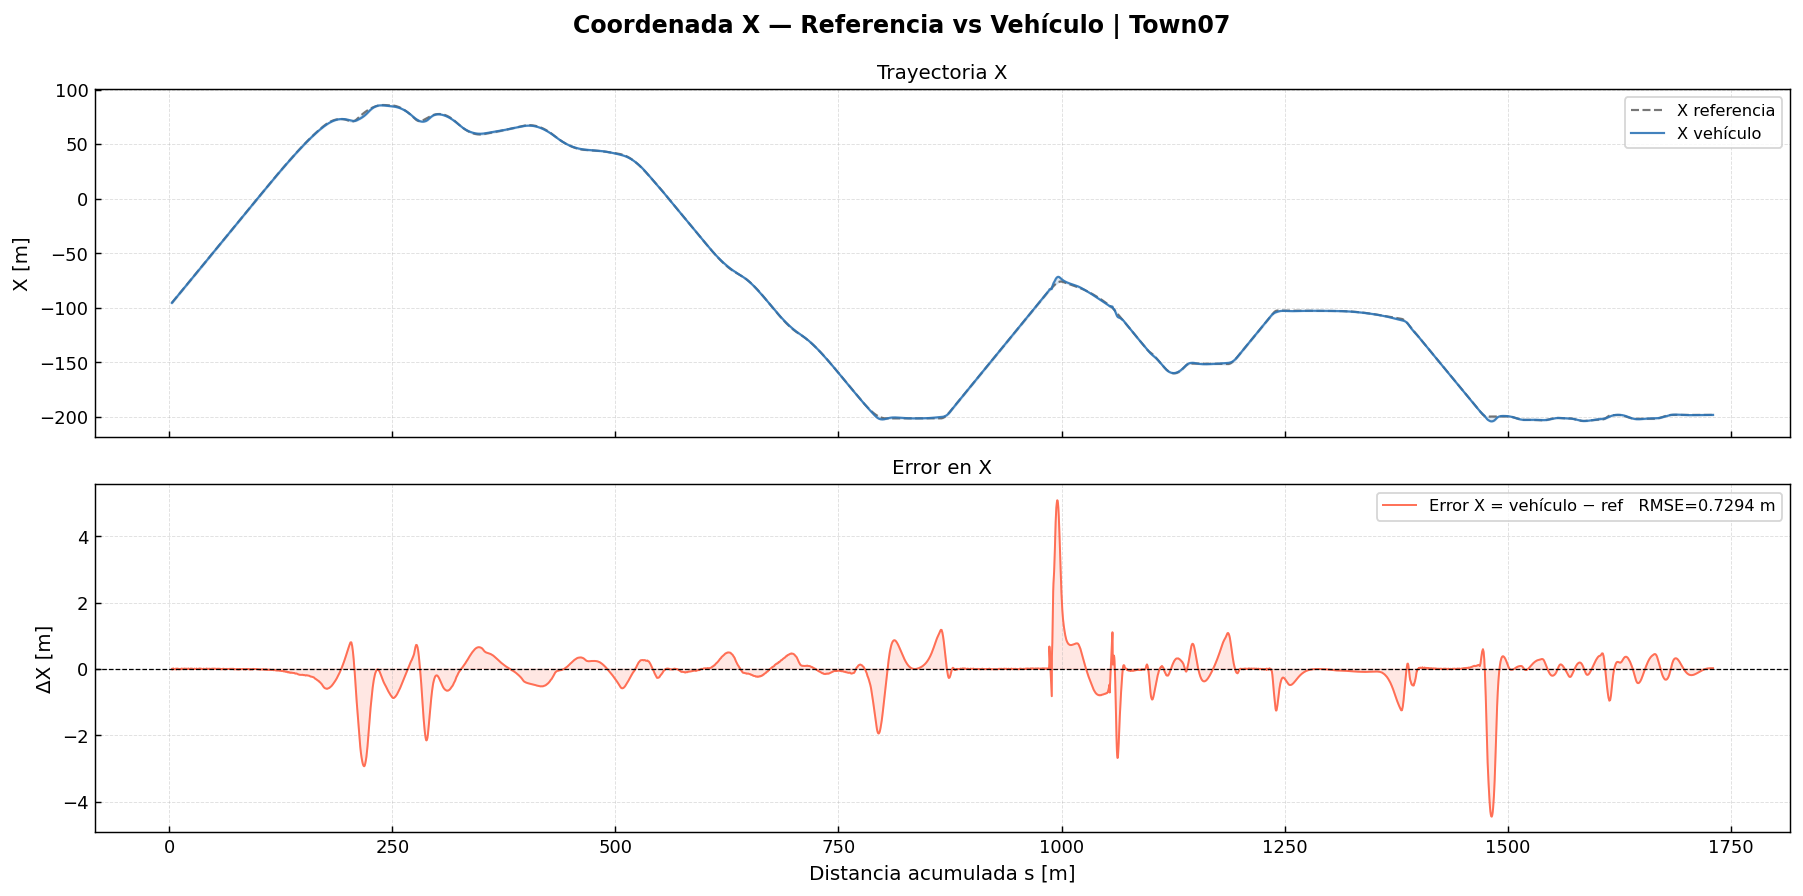

RMSE_X = 0.7294 m
Guardada: stanley_town07_X_vs_s.png


In [9]:

# C07 — Posición X: referencia vs vehículo
x_ref_at_s = np.interp(s_v_arr, s_ref, x_ref)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
fig.suptitle('Coordenada X — Referencia vs Vehículo | Town07', fontweight='bold')

ax0 = axes[0]
ax0.plot(s_v_arr, x_ref_at_s, color=C_REF,  lw=1.2, ls='--', alpha=0.8, label='X referencia')
ax0.plot(s_v_arr, x_v,        color=C_MAIN, lw=1.2, alpha=0.9, label='X vehículo')
ax0.fill_between(s_v_arr, x_ref_at_s, x_v, alpha=0.15, color=C_MAIN)
ax0.set_ylabel('X [m]')
ax0.set_title('Trayectoria X', fontsize=11)
ax0.legend(fontsize=9); ax0.grid(True, ls='--'); ax0.tick_params(direction='in')

ax1 = axes[1]
err_x = x_v - x_ref_at_s
rmse_x = float(np.sqrt(np.mean(err_x**2)))
ax1.plot(s_v_arr, err_x, color='tomato', lw=1.1, alpha=0.9,
         label=f'Error X = vehículo − ref   RMSE={rmse_x:.4f} m')
ax1.axhline(0, color='k', lw=0.7, ls='--')
ax1.fill_between(s_v_arr, err_x, 0, where=(err_x > 0), alpha=0.15, color='tomato')
ax1.fill_between(s_v_arr, err_x, 0, where=(err_x < 0), alpha=0.15, color='tomato')
ax1.set_xlabel('Distancia acumulada s [m]')
ax1.set_ylabel('ΔX [m]')
ax1.set_title('Error en X', fontsize=11)
ax1.legend(fontsize=9); ax1.grid(True, ls='--'); ax1.tick_params(direction='in')

plt.tight_layout()
plt.savefig('stanley_town07_X_vs_s.png', dpi=300)
plt.show()
print(f'RMSE_X = {rmse_x:.4f} m')
print('Guardada: stanley_town07_X_vs_s.png')


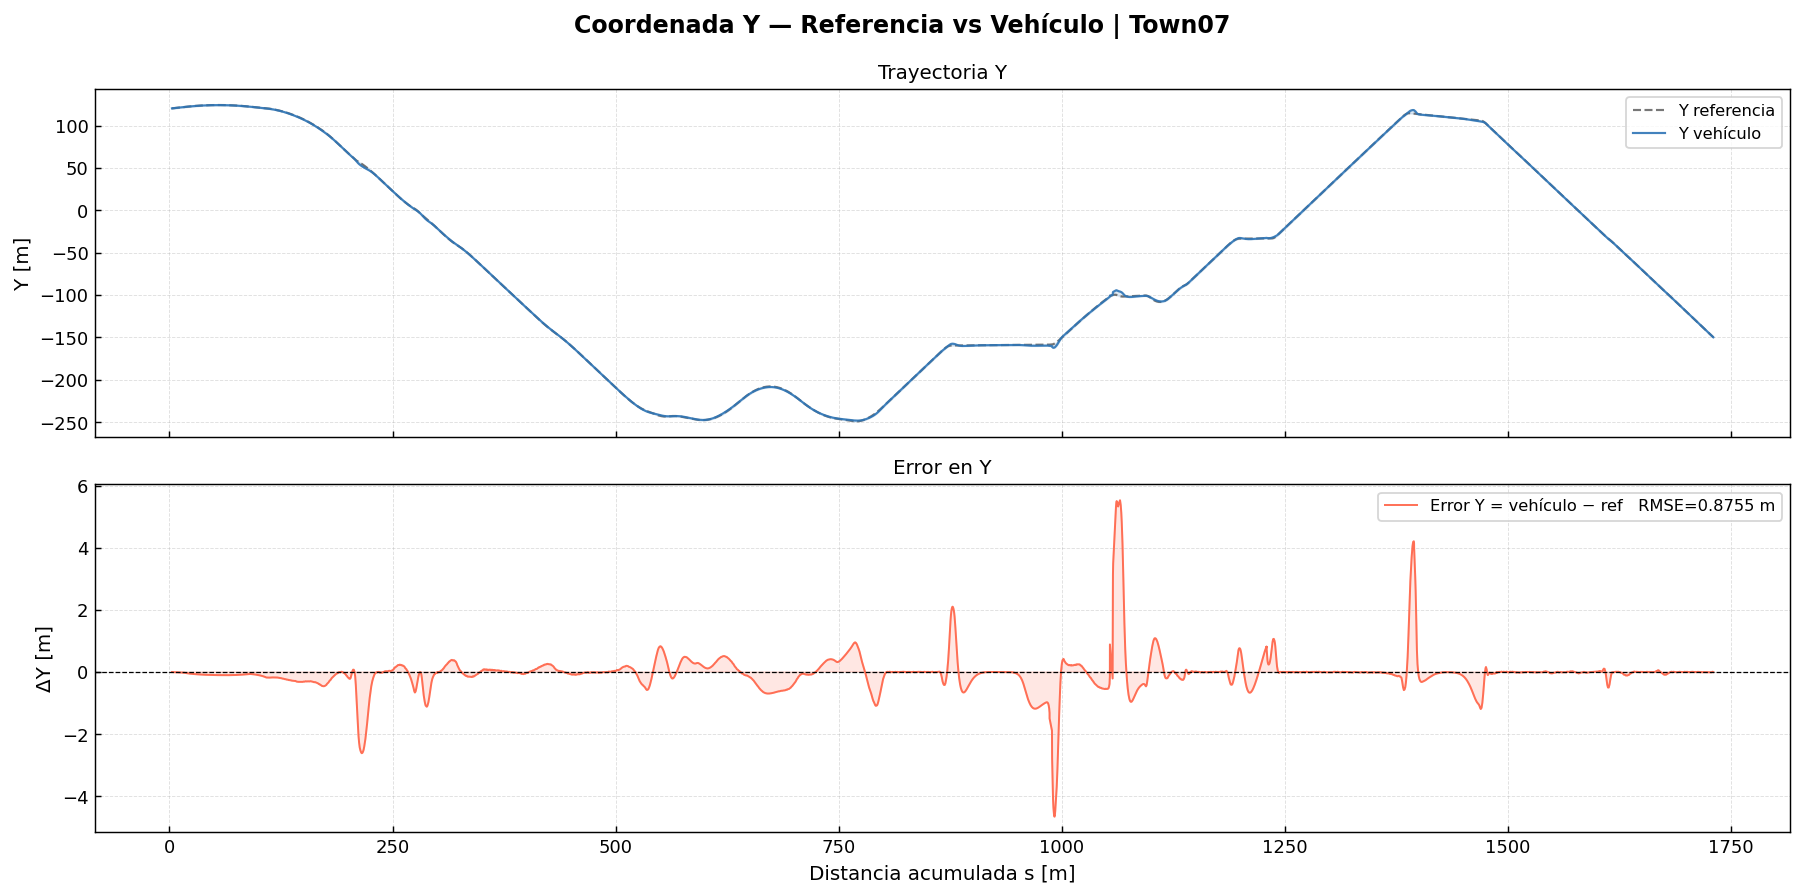

RMSE_Y = 0.8755 m
Guardada: stanley_town07_Y_vs_s.png


In [10]:

# C08 — Posición Y: referencia vs vehículo
y_ref_at_s = np.interp(s_v_arr, s_ref, y_ref)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
fig.suptitle('Coordenada Y — Referencia vs Vehículo | Town07', fontweight='bold')

ax0 = axes[0]
ax0.plot(s_v_arr, y_ref_at_s, color=C_REF,  lw=1.2, ls='--', alpha=0.8, label='Y referencia')
ax0.plot(s_v_arr, y_v,        color=C_MAIN, lw=1.2, alpha=0.9, label='Y vehículo')
ax0.fill_between(s_v_arr, y_ref_at_s, y_v, alpha=0.15, color=C_MAIN)
ax0.set_ylabel('Y [m]')
ax0.set_title('Trayectoria Y', fontsize=11)
ax0.legend(fontsize=9); ax0.grid(True, ls='--'); ax0.tick_params(direction='in')

ax1 = axes[1]
err_y = y_v - y_ref_at_s
rmse_y = float(np.sqrt(np.mean(err_y**2)))
ax1.plot(s_v_arr, err_y, color='tomato', lw=1.1, alpha=0.9,
         label=f'Error Y = vehículo − ref   RMSE={rmse_y:.4f} m')
ax1.axhline(0, color='k', lw=0.7, ls='--')
ax1.fill_between(s_v_arr, err_y, 0, where=(err_y > 0), alpha=0.15, color='tomato')
ax1.fill_between(s_v_arr, err_y, 0, where=(err_y < 0), alpha=0.15, color='tomato')
ax1.set_xlabel('Distancia acumulada s [m]')
ax1.set_ylabel('ΔY [m]')
ax1.set_title('Error en Y', fontsize=11)
ax1.legend(fontsize=9); ax1.grid(True, ls='--'); ax1.tick_params(direction='in')

plt.tight_layout()
plt.savefig('stanley_town07_Y_vs_s.png', dpi=300)
plt.show()
print(f'RMSE_Y = {rmse_y:.4f} m')
print('Guardada: stanley_town07_Y_vs_s.png')
